## Revision : LSTM

##### basic overlook at the LSTM based concepts, targeting single feature 
##### and trying to get back to the concepts

In [1]:
### Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### api key, keeping it hidden
load_dotenv('../keys.txt')
key = os.getenv('key')

In [3]:
### loading the data for Microsoft
df_MSFT = pdr.get_data_tiingo('MSFT', api_key = key)
df_MSFT.head()

close      high     low     open    volume  \
symbol date                                                                     
MSFT   2021-04-28 00:00:00+00:00  254.56  256.5399  252.95  256.078  46903119   
       2021-04-29 00:00:00+00:00  252.51  256.1000  249.00  255.460  40589023   
       2021-04-30 00:00:00+00:00  252.18  253.0800  249.60  249.740  30945098   
       2021-05-03 00:00:00+00:00  251.86  254.3500  251.12  253.400  19626568   
       2021-05-04 00:00:00+00:00  247.79  251.2100  245.76  250.970  32756052   

                                    adjClose     adjHigh      adjLow  \
symbol date                                                            
MSFT   2021-04-28 00:00:00+00:00  244.245771  246.145450  242.701005   
       2021-04-29 00:00:00+00:00  242.278833  245.723374  238.911051   
       2021-04-30 00:00:00+00:00  241.962204  242.825738  239.486740   
       2021-05-03 00:00:00+00:00  241.655169  244.044280  240.945153   
       2021-05-04 00:00:00+00:00  237.750077  241.031506  235.802328   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
MSFT   2021-04-28 00:00:00+00:00  245.702265   46903119      0.0          1.0  
       2021-04-29 00:00:00+00:00  245.109305   40589023      0.0          1.0  
       2021-04-30 00:00:00+00:00  239.621067   30945098      0.0          1.0  
       2021-05-03 00:00:00+00:00  243.132772   19626568      0.0          1.0  
       2021-05-04 00:00:00+00:00  240.801230   32756052      0.0          1.0

In [4]:
### tageting the 4 features at the time : close, high, low and open
features_to_target = ['close', 'high', 'low', 'open']
df_stock_MSFT = df_MSFT[features_to_target].values
df_stock_MSFT

array([[254.56  , 256.5399, 252.95  , 256.078 ],
       [252.51  , 256.1   , 249.    , 255.46  ],
       [252.18  , 253.08  , 249.6   , 249.74  ],
       ...,
       [415.75  , 423.66  , 411.4101, 419.885 ],
       [424.62  , 424.95  , 415.8   , 416.97  ],
       [424.82  , 427.11  , 417.0701, 422.375 ]])

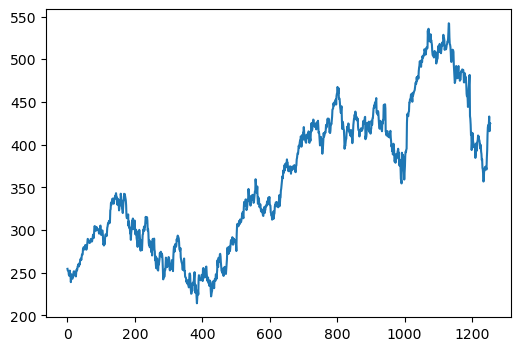

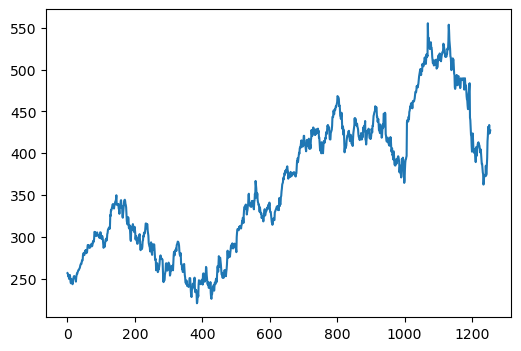

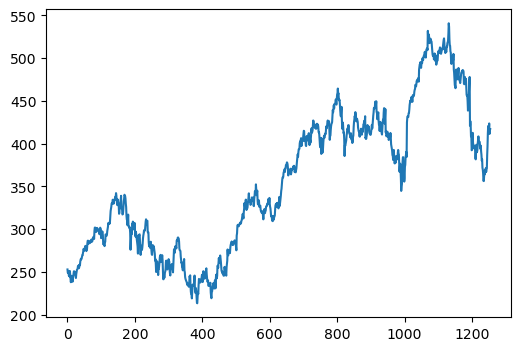

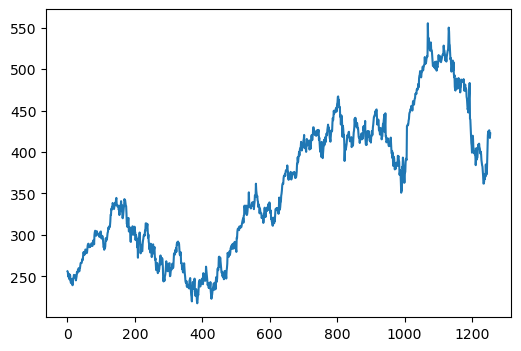

In [ ]:
### plotting the graphs
for i in range (0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [6]:
### applying the minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df_stock_MSFT = scaler.fit_transform(df_stock_MSFT)
df_stock_MSFT

array([[0.12296382, 0.10783757, 0.12072805, 0.11409788],
       [0.11671039, 0.10652459, 0.10866105, 0.11226771],
       [0.11570374, 0.09751074, 0.11049401, 0.09532835],
       ...,
       [0.61466659, 0.60664398, 0.60481366, 0.59920041],
       [0.64172412, 0.61049427, 0.61822453, 0.59056785],
       [0.64233421, 0.61694126, 0.62210461, 0.60657437]])

In [7]:
### checking the shape
df_stock_MSFT.shape

(1255, 4)

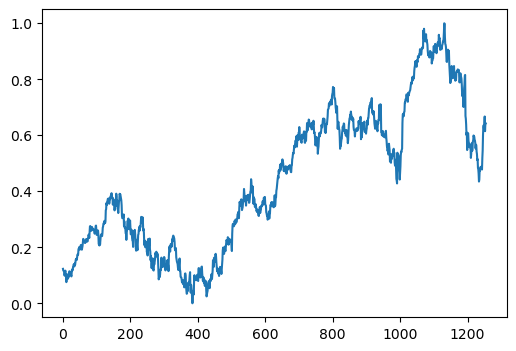

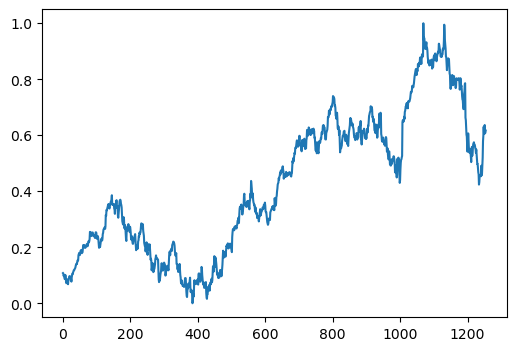

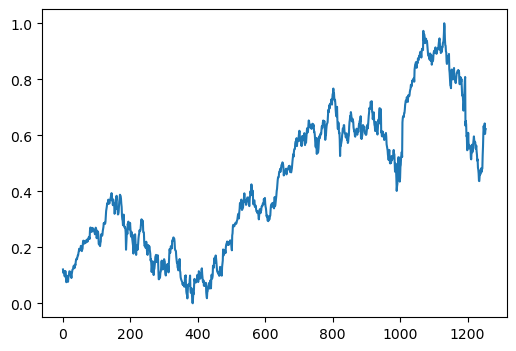

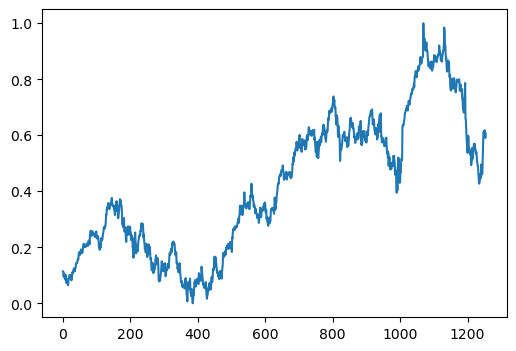

In [8]:
### plotting the graphs again for the comparison
for i in range(0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [9]:
### making the sequnces, target 90 days sequence
days = 90
X, y = [], []
for i in range(len(df_stock_MSFT) - days) : 

    X.append(df_stock_MSFT[i : i + days, :])
    y.append(df_stock_MSFT[i + days , :])

X = np.array(X)
y = np.array(y)

In [10]:
### checking the sequnces (X and y)
X

array([[[0.12296382, 0.10783757, 0.12072805, 0.11409788],
        [0.11671039, 0.10652459, 0.10866105, 0.11226771],
        [0.11570374, 0.09751074, 0.11049401, 0.09532835],
        ...,
        [0.26731133, 0.25098496, 0.26904524, 0.2572592 ],
        [0.26715881, 0.25304441, 0.26901469, 0.25265418],
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483]],

       [[0.11671039, 0.10652459, 0.10866105, 0.11226771],
        [0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        ...,
        [0.26715881, 0.25304441, 0.26901469, 0.25265418],
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483],
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ]],

       [[0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        ...,
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483],
        [0.26505399, 0.245313

In [11]:
### checking the y
y

array([[0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
       [0.26212556, 0.24080707, 0.25896395, 0.24714592],
       [0.26221707, 0.2393744 , 0.25671888, 0.24351818],
       ...,
       [0.61466659, 0.60664398, 0.60481366, 0.59920041],
       [0.64172412, 0.61049427, 0.61822453, 0.59056785],
       [0.64233421, 0.61694126, 0.62210461, 0.60657437]])

In [12]:
### at 91th index of X should match the 1st index of y
print(f"{X.shape} :: {y.shape}")

(1165, 90, 4) :: (1165, 4)


In [13]:
### veryfying the sequences
X[2][89]

array([0.26212556, 0.24080707, 0.25896395, 0.24714592])

In [14]:
### spliting the train-test data (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [15]:
### checking the shape
print(f"{X_train.shape} : {y_train.shape} :: {X_test.shape} : {y_test.shape}")

(932, 90, 4) : (932, 4) :: (233, 90, 4) : (233, 4)


In [16]:
### importing the tesnorflow libraries to build the model
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

In [17]:
### building the sequential model
model = Sequential([
    LSTM(50, return_sequences = True, input_shape = (days, 4)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(4, activation = 'linear')
])
model.compile(optimizer = 'rmsprop', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
### checking the model summary now
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,604 (517.98 KB)

 Trainable params: 132,604 (517.98 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
### training the model
model.fit(X_train, y_train, epochs = 40, batch_size = 32, verbose = 1)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0514 - mse: 0.0514
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0116 - mse: 0.0116
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0102 - mse: 0.0102
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0094 - mse: 0.0094
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0079 - mse: 0.0079
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0069 - mse: 0.0069
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0083 - mse: 0.0083
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0065 - mse: 0.0065
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0056 - mse: 0.0056
Epoch 10/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0042 - mse: 0.0042
Epoch 11/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0052 - mse: 0.0052
Epoch 12/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0041 - mse: 0.0041
Epoch 13/40
30/30 ━━━━━━━━━━━━━━━━━━━

In [20]:
### predictions by the model
y_pred = model.predict(X_test)
y_pred

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


array([[0.31916493, 0.3095835 , 0.31414726, 0.3010738 ],
       [0.61307704, 0.60189575, 0.6086767 , 0.5896309 ],
       [0.8068069 , 0.79344344, 0.8043321 , 0.7820912 ],
       [0.68028426, 0.6683234 , 0.67725784, 0.6570766 ],
       [0.23884156, 0.2319391 , 0.23280069, 0.22388685],
       [0.59236574, 0.58359474, 0.58929026, 0.57270014],
       [0.11722572, 0.1116586 , 0.11110312, 0.10365745],
       [0.0685533 , 0.06448927, 0.06169022, 0.05672053],
       [0.35332146, 0.34429696, 0.34840813, 0.33618164],
       [0.50840306, 0.49823835, 0.5032097 , 0.48742706],
       [0.09122257, 0.08713573, 0.0852282 , 0.07974213],
       [0.35355833, 0.34493166, 0.34920216, 0.33686972],
       [0.3536861 , 0.3450031 , 0.34905773, 0.33656824],
       [0.35602823, 0.34699067, 0.35164934, 0.33905596],
       [0.17332992, 0.16692415, 0.16687074, 0.15853667],
       [0.36350098, 0.35593665, 0.3598063 , 0.3481239 ],
       [0.36333853, 0.35351512, 0.35777375, 0.34485888],
       [0.6643599 , 0.6534394 ,

In [21]:
### y_pred.shape
y_pred.shape

(233, 4)

In [22]:
### inverse scaling the data
y_pred = scaler.inverse_transform(y_pred)
y_pred

array([[318.87863, 324.13284, 316.26364, 319.2151 ],
       [415.22894, 422.06915, 412.6746 , 416.65363],
       [478.73746, 486.24527, 476.72025, 481.64267],
       [437.2608 , 444.32507, 435.1239 , 439.4283 ],
       [292.54706, 298.11887, 289.63574, 293.151  ],
       [408.43936, 415.9376 , 406.32867, 410.93652],
       [252.67894, 257.8201 , 249.79938, 252.55254],
       [236.72314, 242.01648, 233.62462, 236.7031 ],
       [330.07584, 335.76328, 327.47858, 331.07013],
       [380.9147 , 387.33978, 378.15115, 382.14194],
       [244.15459, 249.60396, 241.32951, 244.47693],
       [330.1535 , 335.97592, 327.73846, 331.3025 ],
       [330.1954 , 335.99985, 327.69122, 331.20068],
       [330.96317, 336.66574, 328.53955, 332.04074],
       [271.071  , 276.33627, 268.0543 , 271.0839 ],
       [333.4129 , 339.663  , 331.20963, 335.10275],
       [333.35962, 338.8517 , 330.54428, 334.00024],
       [432.0405 , 439.33832, 430.00848, 434.4564 ],
       [404.6959 , 411.84427, 401.92737, 406.2

In [23]:
### inverse scaling the y_test for the comparison
y_test = scaler.inverse_transform(y_test)
y_test

array([[333.13  , 333.45  , 330.    , 330.31  ],
       [406.35  , 416.16  , 406.3   , 415.36  ],
       [498.41  , 502.25  , 497.7   , 501.43  ],
       [467.56  , 468.35  , 458.965 , 459.61  ],
       [295.92  , 303.13  , 294.05  , 302.89  ],
       [409.54  , 417.11  , 409.    , 416.    ],
       [258.35  , 264.2   , 257.1   , 259.542 ],
       [240.35  , 240.91  , 237.09  , 237.97  ],
       [324.9   , 336.76  , 323.02  , 335.71  ],
       [390.58  , 392.24  , 387.395 , 390.13  ],
       [235.87  , 236.6   , 226.05  , 226.24  ],
       [340.54  , 342.73  , 337.2   , 337.75  ],
       [338.7   , 340.86  , 336.57  , 339.148 ],
       [342.66  , 343.74  , 339.02  , 339.56  ],
       [270.02  , 273.45  , 268.41  , 270.31  ],
       [327.5   , 333.63  , 326.3551, 333.63  ],
       [336.32  , 339.355 , 335.85  , 338.51  ],
       [436.6   , 443.74  , 428.63  , 433.11  ],
       [423.03  , 424.44  , 417.2   , 418.25  ],
       [296.31  , 297.28  , 293.49  , 294.91  ],
       [521.77  , 52

In [28]:
### finding out the comparsion/evaluation metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
for i in range (0, 4) :
    print(f"feature : {features_to_target[i]}")
    print(mean_squared_error(y_test, y_pred))
    print(mean_absolute_error(y_test, y_pred))
    print(root_mean_squared_error(y_test, y_pred))

feature : close
199.55214253149978
10.949464195598555
14.097713556148573
feature : high
199.55214253149978
10.949464195598555
14.097713556148573
feature : low
199.55214253149978
10.949464195598555
14.097713556148573
feature : open
199.55214253149978
10.949464195598555
14.097713556148573


In [29]:
def plot_predictions(y_test, y_pred) : 
    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

feature : close


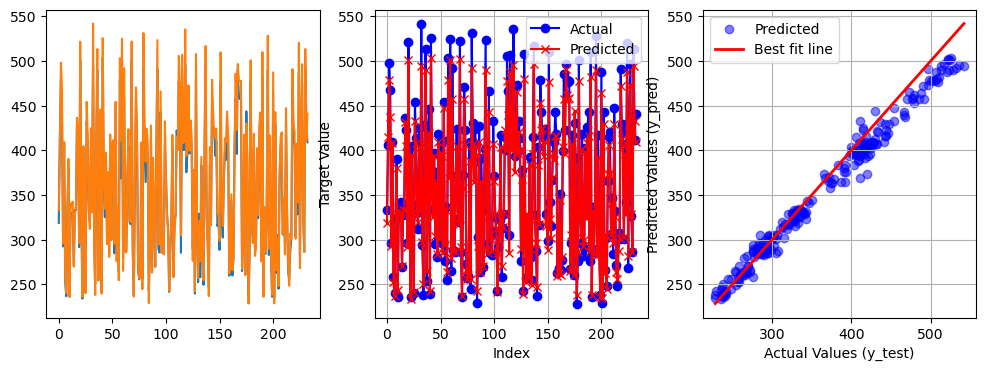

feature : high


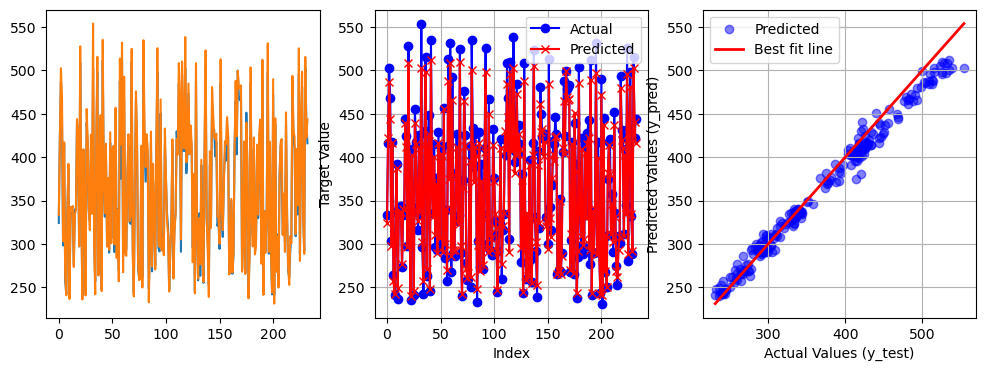

feature : low


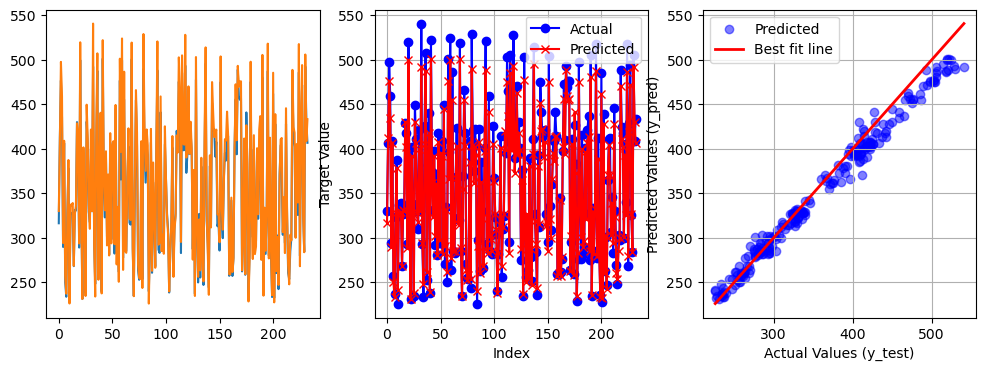

feature : open


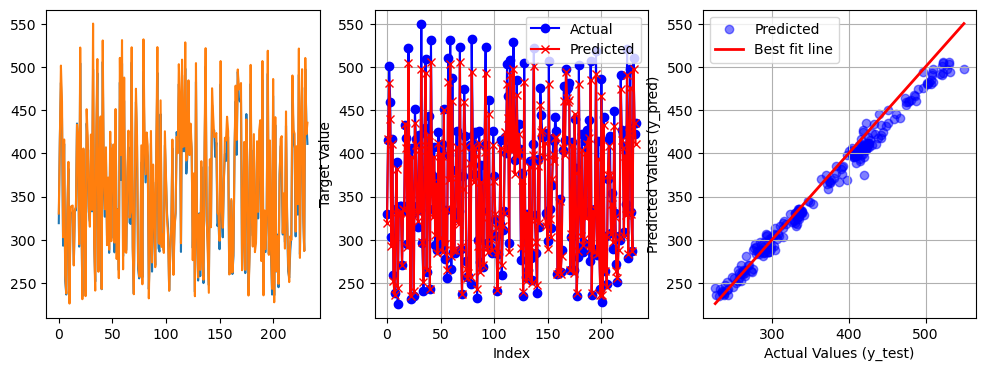

In [32]:
### plotting the comparison graphs now
for i in range(0, 4) : 
    print(f"feature : {features_to_target[i]}")
    plot_predictions(y_test[:, i], y_pred[:, i])